# Configuración básica (no tocar)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [3]:
x = Variable()

# Implementación de métodos

In [4]:
# Implementar para hallar raíces de las derivadas, no de f

#Método de Bisección
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    g = f.derivative()
    fa = g.eval(a)
    fb = g.eval(b)
    if fa == 0:
        return (a, 0, [a]) if return_path else (a, 0)
    if fb == 0:
        return (b, 0, [b]) if return_path else (b, 0)
    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en el intervalo dado.")
    path = []
    xn = a
    for step in range(1, max_iter + 1):
        xn = 0.5 * (a + b)
        path.append(xn)
        fxn = g.eval(xn)
        if abs(fxn) < tol or 0.5 * (b - a) < tol:
            return (xn, step, path) if return_path else (xn, step)
        if fa * fxn > 0:
            a = xn
            fa = fxn
        else:
            b = xn
            fb = fxn
    return (xn, max_iter, path) if return_path else (xn, max_iter)

#Método de Newton
def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    g = f.derivative()
    g2 = g.derivative()
    xn = x0
    path = [xn]
    for step in range(1, max_iter + 1):
        gx = g.eval(xn)
        if abs(gx) < tol:
            return (xn, step, path) if return_path else (xn, step)
        g2x = g2.eval(xn)
        if abs(g2x) < 1e-12:
            return (xn, step, path) if return_path else (xn, step)
        xn_next = xn - gx / g2x
        path.append(xn_next)
        if abs(xn_next - xn) < tol:
            return (xn_next, step, path) if return_path else (xn_next, step)
        xn = xn_next
    return (xn, max_iter, path) if return_path else (xn, max_iter)

#Método de Descenso por Gradiente
def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000, return_path: bool = False):
    grad = f.derivative()
    xn = x0
    path = [xn]
    for step in range(1, max_iter + 1):
        gx = grad.eval(xn)
        if abs(gx) < tol:
            return (xn, step, path) if return_path else (xn, step)
        xn_next = xn - lr * gx
        path.append(xn_next)
        if abs(xn_next - xn) < tol:
            return (xn_next, step, path) if return_path else (xn_next, step)
        xn = xn_next
    return (xn, max_iter, path) if return_path else (xn, max_iter)

### Prueba de métodos

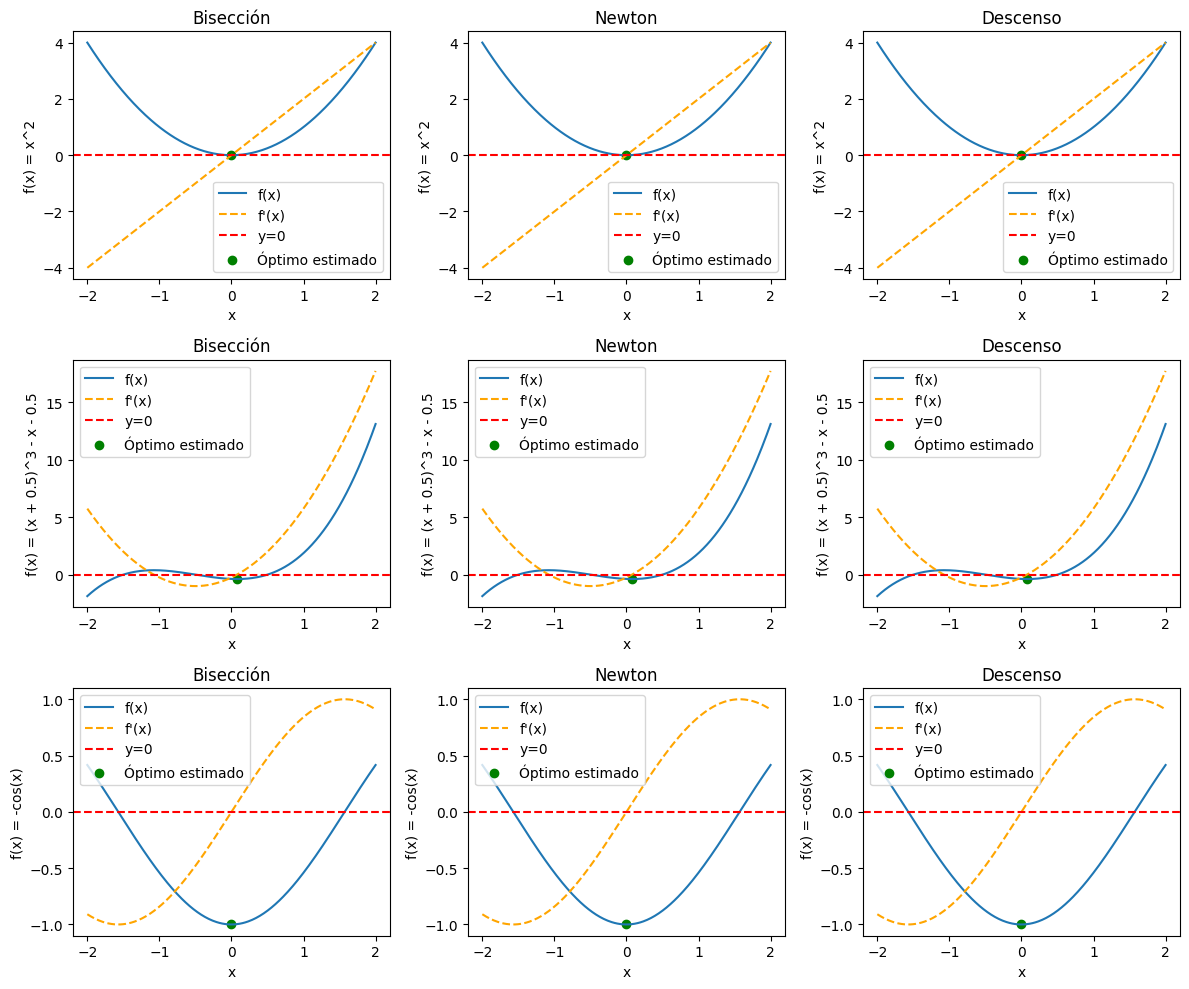

In [ ]:
#Verificación de métodos con funciones simples
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        metodo = methods[j]
        params = parameters[j]
        res, step = metodo(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

In [ ]:
# Verificación de funcionamiento
print("\nVerificación de los valores de extremo esperados:")
for i, f in enumerate(functions):
    name = y_labels[i]
    res_bis, _ = biseccion(f, -1, 1)
    res_new, _ = newton(f, 1)
    res_gd, _ = descenso_gradiente(f, 1, 1e-2)

    if i == 0:
        expected = [0.0]
        expected_desc = "x=0"
    elif i == 1:
        expected = [-0.5 - 1/np.sqrt(3), -0.5 + 1/np.sqrt(3)]
        expected_desc = "x ≈ -1.07735 o x ≈ 0.07735"
    else:
        expected = [0.0]
        expected_desc = "x=0 (raíz más cercana de -sin(x) en [-1,1])"

    def check(value):
        return any(np.isclose(value, e, atol=1e-4) for e in expected)

    print(f"\n{name}")
    print(f"  Bisección -> {res_bis}  {'OK' if check(res_bis) else 'ERROR'}")
    print(f"  Newton -> {res_new}  {'OK' if check(res_new) else 'ERROR'}")
    print(f"  Descenso -> {res_gd}  {'OK' if check(res_gd) else 'ERROR'}")
    print(f"  Esperado: {expected_desc}")


Verificación de los valores de extremo esperados:

f(x) = x^2
  Bisección -> 0.0  OK
  Newton -> 0.0  OK
  Descenso -> 4.8220225910828e-05  OK
  Esperado: x=0

f(x) = (x + 0.5)^3 - x - 0.5
  Bisección -> 0.07734966278076172  OK
  Newton -> 0.07735026919569789  OK
  Descenso -> 0.07737808501133076  OK
  Esperado: x ≈ -1.07735 o x ≈ 0.07735

f(x) = -cos(x)
  Bisección -> 0.0  OK
  Newton -> 2.923566201412306e-13  OK
  Descenso -> 9.836982761146878e-05  OK
  Esperado: x=0 (raíz más cercana de -sin(x) en [-1,1])


# Aplicación a función no trivial

In [5]:
f = x**2 + 2*sin(3*x)

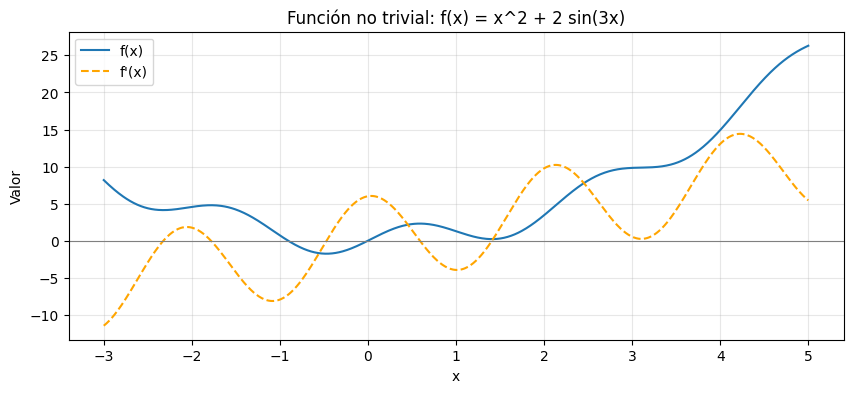

In [7]:
# Gráfica de la función para el intervalo [-3,5]
lp = np.linspace(-3, 5, 800)
plt.figure(figsize=(10, 4))
plt.plot(lp, [f.eval(v) for v in lp], label='f(x)')
plt.plot(lp, [f.derivative().eval(v) for v in lp], linestyle='--', color='orange', label="f'(x)")
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('Valor')
plt.title('Función no trivial: f(x) = x^2 + 2 sin(3x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

             Método Condición inicial                                                 Predicción  Resultado  Iteraciones
          Bisección           [-2, 1]                                  raíz de f' cerca de -1.78  -1.782932           22
          Bisección           [-1, 0]                                  raíz de f' cerca de -0.47  -0.471044           20
          Bisección            [1, 2]                                   raíz de f' cerca de 1.41   1.407956           20
             Newton           x0 = -2             aproxima el mínimo local izquierdo (x ≈ -1.78)  -1.782932            5
             Newton           x0 = -1                 puede cambiar a la raíz central (x ≈ 0.59)   0.589531            5
             Newton            x0 = 4 puede desviarse hacia la región derecha (no converge bien)   7.820892         1000
  Descenso (lr=0.1)           x0 = -3      debería caer en el mínimo local izquierdo (x ≈ -2.32)  -2.322807           16
 Descenso (lr=0.01)           x0

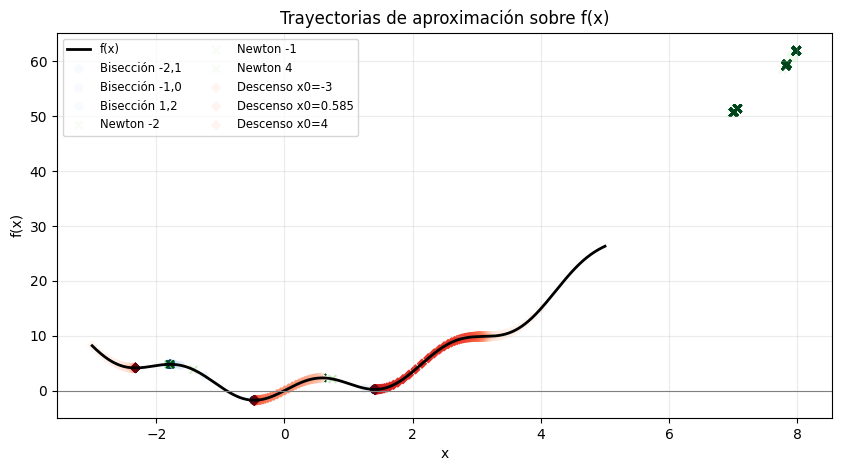

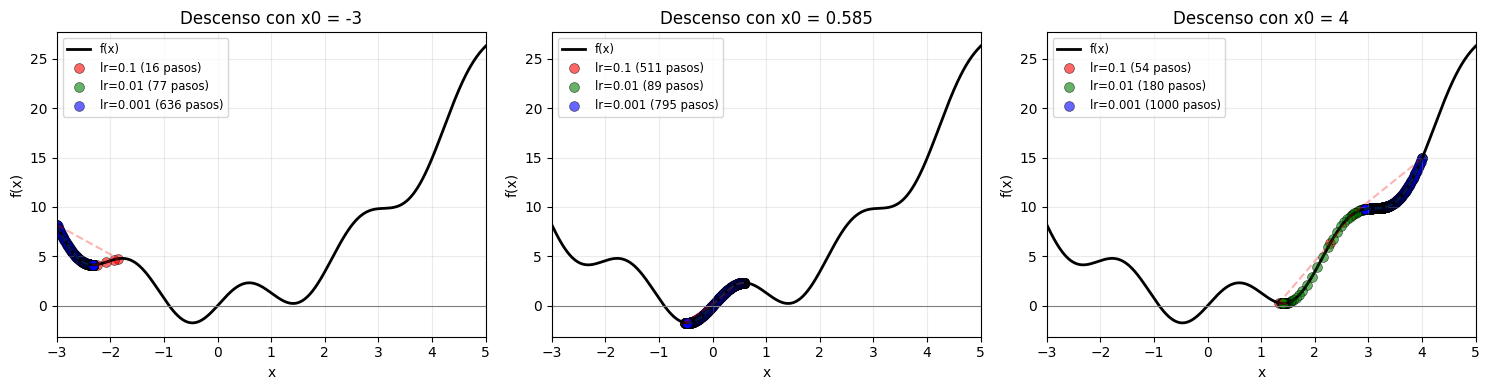

In [8]:
# Evaluación de métodos y generación de tablas
bisec_intervals = [(-2, 1), (-1, 0), (1, 2)]
newton_inits = [-2, -1, 4]
gd_inits = [-3, 0.585, 4]
learning_rates = [0.1, 0.01, 0.001]

rows = []
for a, b in bisec_intervals:
    prediction = {
        (-2, 1): 'raíz de f\' cerca de -1.78',
        (-1, 0): 'raíz de f\' cerca de -0.47',
        (1, 2): 'raíz de f\' cerca de 1.41'
    }[(a, b)]
    res, steps = biseccion(f, a, b)
    rows.append({'Método': 'Bisección', 'Condición inicial': f'[{a}, {b}]', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

for x0 in newton_inits:
    prediction = {
        -2: 'aproxima el mínimo local izquierdo (x ≈ -1.78)',
        -1: 'puede cambiar a la raíz central (x ≈ 0.59)',
        4: 'puede desviarse hacia la región derecha (no converge bien)'
    }[x0]
    res, steps = newton(f, x0)
    rows.append({'Método': 'Newton', 'Condición inicial': f'x0 = {x0}', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

for x0 in gd_inits:
    for lr in learning_rates:
        prediction = {
            -3: 'debería caer en el mínimo local izquierdo (x ≈ -2.32)',
            0.585: 'debería moverse al extremo central (x ≈ -0.47)',
            4: 'debería caer en el mínimo local derecho (x ≈ 1.41)'
        }[x0]
        res, steps = descenso_gradiente(f, x0, lr)
        rows.append({'Método': f'Descenso (lr={lr})', 'Condición inicial': f'x0 = {x0}', 'Predicción': prediction, 'Resultado': res, 'Iteraciones': steps})

summary_df = pd.DataFrame(rows)
print(summary_df.round(6).to_string(index=False))

import inspect

def _path_result(method, *args, **kwargs):
    try:
        return method(*args, return_path=True, **kwargs)
    except TypeError:
        res, steps = method(*args, **kwargs)
        return res, steps, [res]

# Comparación visual de trayectorias para cada método
plt.figure(figsize=(10, 5))
plt.plot(lp, [f.eval(v) for v in lp], label='f(x)', color='black', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.8)

palette = {'Bisección': 'tab:blue', 'Newton': 'tab:green', 'Descenso': 'tab:red'}

for a, b in bisec_intervals:
    _, _, path = _path_result(biseccion, f, a, b)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Blues', s=30, label=f'Bisección {a},{b}')

for x0 in newton_inits:
    _, _, path = _path_result(newton, f, x0)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Greens', s=30, marker='x', label=f'Newton {x0}')

for x0 in [ -3, 0.585, 4 ]:
    _, _, path = _path_result(descenso_gradiente, f, x0, 0.01)
    path_y = [f.eval(v) for v in path]
    plt.scatter(path, path_y, c=np.arange(len(path)), cmap='Reds', s=20, marker='D', label=f'Descenso x0={x0}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectorias de aproximación sobre f(x)')
plt.legend(fontsize='small', ncol=2)
plt.grid(alpha=0.25)
plt.show()

# Comparación de learning rates en descenso por gradiente
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_lr = {0.1: 'red', 0.01: 'green', 0.001: 'blue'}

for idx, x0 in enumerate(gd_inits):
    ax = axes[idx]
    ax.plot(lp, [f.eval(v) for v in lp], label='f(x)', color='black', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8)
    
    for lr in learning_rates:
        _, steps, path = _path_result(descenso_gradiente, f, x0, lr)
        path_y = [f.eval(v) for v in path]
        ax.scatter(path, path_y, c=colors_lr[lr], s=50, alpha=0.6, 
                  label=f'lr={lr} ({steps} pasos)', marker='o', edgecolors='black', linewidth=0.5)
        # Línea conectando puntos para ver la trayectoria
        ax.plot(path, path_y, color=colors_lr[lr], alpha=0.3, linestyle='--')
    
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Descenso con x0 = {x0}')
    ax.legend(fontsize='small')
    ax.grid(alpha=0.25)
    ax.set_xlim(-3, 5)

plt.tight_layout()
plt.show()


# Ajuste de datos

In [9]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [10]:
# Genere la función de pérdida

In [11]:
# Optimice la función de pérdida

In [12]:
# Grafique datos y ajuste

# BONUS: